# Test Log Probability Calculation

This notebook tests the log probability calculation in `utils.py` with varying values of `w` and `k`.

In [1]:
import os
import sys
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt


sys.path.append('./../../scripts/nn/')
from rtdl_num_embeddings_keras import (
    PeriodicEmbeddings,
    PiecewiseLinearEncoding,
    PiecewiseLinearEmbeddings,
)

# Add scripts to path
sys.path.append('../../scripts')

import utils
from utils import load_data_ams
from preprocess import RIGIDITY_VALS
from chi2 import CalculateChi2

Using TensorFlow backend


2026-05-12 08:29:59.677781: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-12 08:29:59.677839: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-12 08:29:59.679337: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-12 08:30:02.957093: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


## Load Data

In [2]:
data_path = '../../data/AMS02_H-PRL2021_split_uncertainty/20110520-20110610.dat'
integrate = True
split_uncertainty = True

bins, r1r2_zip, observed, statistical_uncertainty, systematic_uncertainty = load_data_ams(data_path, integrate, split_uncertainty)
r1r2 = list(r1r2_zip) # Convert zip to list

## Mock Neural Network Output

Let's assume the NN predicts something close to the observed data but with some variations.

In [3]:
# Use the observed data to create a 'good' model prediction
# We need to interpolate the observed data back to RIGIDITY_VALS
bin_midpoints = np.sqrt(np.array([r1 for r1, r2 in r1r2]) * np.array([r2 for r1, r2 in r1r2]))
y_true = np.interp(RIGIDITY_VALS, bin_midpoints, observed)

def get_yhat_integrated(yhat_vals):
    log_yhat = jnp.log(yhat_vals)
    log_rigidity = jnp.log(jnp.array(RIGIDITY_VALS))
    chi2_calc = CalculateChi2(log_rigidity, log_yhat)
    
    yhat_interp_integrated = []
    for x1, x2 in r1r2:
        integral = chi2_calc.compute_integral(x1, x2) / (x2 - x1)
        yhat_interp_integrated.append(integral)
    return jnp.asarray(yhat_interp_integrated)

yhat_integrated = get_yhat_integrated(y_true)

## Log Probability Function

Replicating the logic from `utils.py`.

In [4]:
def calculate_log_prob(yhat_interp_integrated, observed, statistical_uncertainty, systematic_uncertainty, w, k, split_uncertainty, nlogprior=0.0):
    yhat = jnp.asarray(yhat_interp_integrated)
    
    if not split_uncertainty:
        uncertainty = jnp.sqrt(statistical_uncertainty**2 + systematic_uncertainty**2)
        chi2 = (((yhat - observed)/uncertainty)**2).sum()
        log_prob = -chi2/2. - nlogprior
        
    else: 
        # sigma1 = sqrt(dF_stat_i^2 + dF_syst_i^2) 
        # sigma2 = sqrt(dF_stat_i^2 + k^2 * dF_syst_i^2)
        # ln L = -chi2(sigma1)/2 + ln { (1 + (1-w)/w*exp[chi2(sigma1)/2 - chi2(sigma2)/2]) }

        sigma1 = jnp.sqrt(statistical_uncertainty**2 + systematic_uncertainty**2)
        sigma2 = jnp.sqrt(statistical_uncertainty**2 + (k**2 * systematic_uncertainty**2))
        
        # Calculate chi2 PER BIN
        chi2_1_i = ((yhat - observed) / sigma1)**2
        chi2_2_i = ((yhat - observed) / sigma2)**2

        if w != 1.0:
            # Per-bin log components EXCLUDING the -ln(sigma) normalization terms
            term1 = jnp.log(w) - (chi2_1_i / 2.)
            term2 = jnp.log(1.0 - w) - (chi2_2_i / 2.)
            
            # calculate ln(exp(term1) + exp(term2)) per bin without overflowing
            log_prob_i = jnp.logaddexp(term1, term2)
            
            # Sum the probabilities over all bins AFTER calculating the mixture
            log_prob = log_prob_i.sum() - nlogprior
            
        else:
            # If w=1, calculate per bin without normalization, then sum
            log_prob_i = -(chi2_1_i / 2.)
            log_prob = log_prob_i.sum() - nlogprior
            
    return log_prob

## Test with Varying w and k

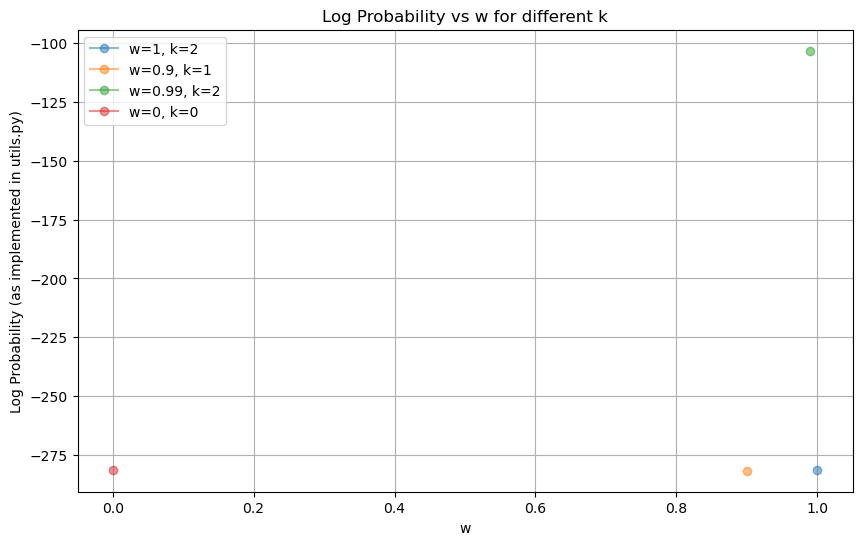

In [5]:
# 1) inference with w = 1 and arbitrary k > 0: 
# 2) inference with arbitrary 0 < w < 1 and k = 1: 

w_ks = [(1, 2), (0.9, 1), (0.99, 2)]

results = {}

for w_k in w_ks:
    w, k = w_k
    results[w_k] = []
    
    lp = calculate_log_prob(yhat_integrated, observed, statistical_uncertainty, systematic_uncertainty, w, k, True)

    if k == 1:
        lp -= np.log(1 + ((1-w)/w))
    
    results[w_k].append(float(lp))

results[(0, 0)] = [calculate_log_prob(yhat_integrated, observed, statistical_uncertainty, systematic_uncertainty, 0, 0, False)]
w_ks.append((0, 0))

plt.figure(figsize=(10, 6))
for w_k in w_ks:
    w, k = w_k
    plt.plot([w], results[w_k], 'o-', label=f'w={w}, k={k}', alpha=0.5)

plt.xlabel('w')
plt.ylabel('Log Probability (as implemented in utils.py)')
plt.title('Log Probability vs w for different k')
plt.legend()
plt.grid(True)
plt.show()